9
[{'text': '• Type - Whole conditions (serial / standalone / component part)', 'offset': -4.0}, {'text': '• Identifier (international, in-house unique identifier number)', 'offset': -3.0}, {'text': '• Titles (original, alternative, series/serial)', 'offset': -2.0}, {'text': '• Country (production country/countries)', 'offset': -1.0}, {'text': '• Dates (copyright / production)', 'offset': 0.0}, {'text': '• Language(s): original language of conception/presentation', 'offset': 1.0}, {'text': '• Notes/History', 'offset': 2.0}, {'text': '• Content: Synopsis, Genre, Form, Subject', 'offset': 3.0}, {'text': '• Agents: Cast, Credits, Rights holders', 'offset': 4.0}]
(1500, 1000, 3)


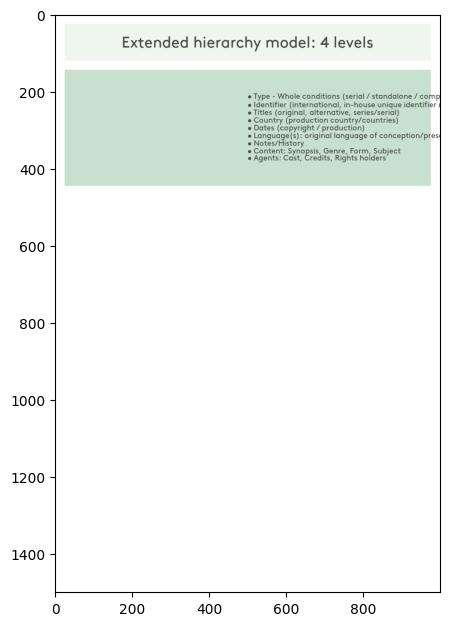

In [26]:
# notebook to work on opencv diagrams for FIAF cat manual.

import cv2
import matplotlib.pylab as plt
import numpy
import pathlib
import skimage
from PIL import Image, ImageDraw, ImageFont


def font(weight, size):

    ''' Define a font object. '''

    font_path = pathlib.Path.cwd().parents[0] / 'font' / f'BrownStd{weight}.otf'
    if not font_path.exists():
        raise Exception('Font OTF does not exist.')
    
    return ImageFont.truetype(str(font_path), size)

def draw_rectangle(name, x, y, w, h, colour):
    
    ''' Define a rectangle shape. '''

    cv2.rectangle(canvas, (x, y), (x+w, y+h), colour, -1) 
    elements[name] = {'x':x, 'y':y, 'w':w, 'h':h}

def draw_text_by_anchor(anchor, text, text_weight, text_size, center, y_offset_iterate):

    font_object = font(text_weight, text_size)

   
    anchor_coords = elements[anchor]
    center_x = anchor_coords['x']+(anchor_coords['w']/2)
    center_y = anchor_coords['y']+(anchor_coords['h']/2)

    text_bbox = font_object.getbbox(text[:4])
    center_y = center_y-(text_bbox[3]/2)

    center_y = center_y + (y_offset_iterate*20)



    if center:
        text_bbox = font_object.getbbox(text)
        center_x = center_x-(text_bbox[2]/2)

   


    draw.text((int(center_x), int(center_y)), text, font=font_object, fill="#444444")

def render_preview(path):

    preview = cv2.cvtColor(cv2.imread(path, -1), cv2.COLOR_BGR2RGB) 
    print(preview.shape)
    plt.figure(figsize=(7.5,7.5))
    plt.imshow(skimage.img_as_float32(preview))
    plt.show()  

img_path = pathlib.Path.cwd() / 'test.png'

canvas_w, canvas_h = 1000, 1500
canvas = numpy.zeros((canvas_h, canvas_w, 3), numpy.uint8)
canvas[:, :] = (255, 255, 255)

elements = dict()
draw_rectangle('header', 25, 25, 950, 95, (239, 246, 238))

draw_rectangle('layer_1', 25, 145, 950, 300, (206, 225, 199))



cv2.imwrite(img_path, canvas)

image_data = Image.open(img_path)
draw = ImageDraw.Draw(image_data)



draw_text_by_anchor('header', 'Extended hierarchy model: 4 levels', 'Regular', 40, True, 0)


# mathematically calculate offsets.


layer_1_text = ['• Type - Whole conditions (serial / standalone / component part)',
    '• Identifier (international, in-house unique identifier number)',
    '• Titles (original, alternative, series/serial)',
    '• Country (production country/countries)',
    '• Dates (copyright / production)',
    '• Language(s): original language of conception/presentation',
    '• Notes/History',
    '• Content: Synopsis, Genre, Form, Subject',
    '• Agents: Cast, Credits, Rights holders']

layer_1_text = [{'text':x, 'offset':i-((len(layer_1_text)-1)/2)} for i,x in enumerate(layer_1_text)]

print(len(layer_1_text))



print(layer_1_text)

for x in layer_1_text:
    draw_text_by_anchor('layer_1', x['text'], 'Regular', 20, False, x['offset'])




image_data.save(img_path)




render_preview(img_path)

In [9]:
(950/1253)*400

303.2721468475658